##### Copyright 2019 The TensorFlow Authors.
##### 2022-24 P.Huttunen.

In [1]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

#### Print your name

In [2]:
## Your code here 
print("Exercise by: Valtteri Airaksinen") 

Exercise by: Valtteri Airaksinen


# Image Classification using tf.keras

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l05c03_exercise_flowers_with_data_augmentation.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/examples/blob/master/courses/udacity_intro_to_tensorflow_for_deep_learning/l05c03_exercise_flowers_with_data_augmentation.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

In this Colab you will classify images of flowers. You will build an image classifier using `tf.keras.Sequential` model and load data using `tf.keras.preprocessing.image.ImageDataGenerator`.


# Importing Packages

Let's start by importing required packages. **os** package is used to read files and directory structure, **numpy** is used to convert python list to numpy array and to perform required matrix operations and **matplotlib.pyplot** is used to plot the graph and display images in our training and validation data.

In [3]:
import os
import time
import numpy as np
import glob
import shutil

import matplotlib.pyplot as plt

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

### TODO: Import TensorFlow and Keras Layers

In the cell below, import Tensorflow as `tf` and Keras and packages you will need to build your CNN. Also, import the `ImageDataGenerator` so that you can perform image augmentation.

```python
# Import os, plt, tf, keras and ImageDataGenerator
```


In [4]:
## Task 1:
## Your code here 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

tf.get_logger().setLevel("ERROR")

2026-04-26 20:57:12.110227: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777226232.127011  930174 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777226232.132257  930174 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
print('Tensorflow version:', tf.__version__)
print('Keras version:', keras.__version__)

Tensorflow version: 2.18.0
Keras version: 3.6.0


In [6]:
# Jaetaan ympäristössä oleva 1 fyysinen GPU N:ksi loogiseksi GPU:ksi

N_of_GPUs = 4 #Tehtävänannon mukaan konfiguroidaan 4:ksi loogiseksi GPU:ksi

physical_gpus = tf.config.list_physical_devices('GPU')

if physical_gpus:
    try:
        tf.config.set_logical_device_configuration(
            physical_gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=2048) for _ in range(N_of_GPUs)]
        )
        print(f"Configured 1 physical GPU as {N_of_GPUs} logical GPUs.")
    except Exception as e:
        print("Logical GPU configuration was skipped:")
        print(e)
else:
    print("No physical GPU found. The notebook will run on CPU if necessary.")

logical_gpus = tf.config.list_logical_devices('GPU')
print("Physical GPUs:", len(physical_gpus))
print("Logical GPUs:", len(logical_gpus))


Configured 1 physical GPU as 4 logical GPUs.
Physical GPUs: 1
Logical GPUs: 4


I0000 00:00:1777226233.991638  930174 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2048 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:62:00.0, compute capability: 7.0
I0000 00:00:1777226233.992536  930174 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 2048 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:62:00.0, compute capability: 7.0
I0000 00:00:1777226233.992746  930174 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 2048 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:62:00.0, compute capability: 7.0
I0000 00:00:1777226233.993079  930174 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 2048 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:62:00.0, compute capability: 7.0


# Data Loading

In order to build our image classifier, we can begin by downloading the flowers dataset. We first need to download the archive version of the dataset and after the download we are storing it to "/tmp/" directory.

After downloading the dataset, we need to extract its contents.

In [7]:
# NOTE: Do not use if you run this in jupyterhub.dclabra.fi Use shared data instead.

# _URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
# 
# zip_file = tf.keras.utils.get_file(origin=_URL,
#                                    fname="flower_photos.tgz",
#                                    extract=True)
# 
# base_dir = os.path.join(os.path.dirname(zip_file), 'flower_photos')
# print(base_dir)

In [8]:
# NOTE: Use shared data in jupyterhub.dclabra.fi
base_dir = "/scratch/project_2018566/data/flower_photos"

The dataset we downloaded contains images of 5 types of flowers:

1. Rose
2. Daisy
3. Dandelion
4. Sunflowers
5. Tulips

So, let's create the labels for these 5 classes: 

In [9]:
classes = ['roses', 'daisy', 'dandelion', 'sunflowers', 'tulips']

Also, the dataset we have downloaded has following directory structure.

<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>flower_photos</b>
|__ <b>daisy</b>
|__ <b>dandelion</b>
|__ <b>roses</b>
|__ <b>sunflowers</b>
|__ <b>tulips</b>
</pre>

As you can see there are no folders containing training and validation data. Therefore, we will have to create our own training and validation set. Let's write some code that will do this.


The code below creates a `train` and a `val` folder each containing 5 folders (one for each type of flower). It then moves the images from the original folders to these new folders such that 80% of the images go to the training set and 20% of the images go into the validation set. In the end our directory will have the following structure:


<pre style="font-size: 10.0pt; font-family: Arial; line-height: 2; letter-spacing: 1.0pt;" >
<b>flower_photos</b>
|__ <b>daisy</b>
|__ <b>dandelion</b>
|__ <b>roses</b>
|__ <b>sunflowers</b>
|__ <b>tulips</b>
|__ <b>train</b>
    |______ <b>daisy</b>: [1.jpg, 2.jpg, 3.jpg ....]
    |______ <b>dandelion</b>: [1.jpg, 2.jpg, 3.jpg ....]
    |______ <b>roses</b>: [1.jpg, 2.jpg, 3.jpg ....]
    |______ <b>sunflowers</b>: [1.jpg, 2.jpg, 3.jpg ....]
    |______ <b>tulips</b>: [1.jpg, 2.jpg, 3.jpg ....]
 |__ <b>val</b>
    |______ <b>daisy</b>: [507.jpg, 508.jpg, 509.jpg ....]
    |______ <b>dandelion</b>: [719.jpg, 720.jpg, 721.jpg ....]
    |______ <b>roses</b>: [514.jpg, 515.jpg, 516.jpg ....]
    |______ <b>sunflowers</b>: [560.jpg, 561.jpg, 562.jpg .....]
    |______ <b>tulips</b>: [640.jpg, 641.jpg, 642.jpg ....]
</pre>

Since we don't delete the original folders, they will still be in our `flower_photos` directory, but they will be empty. The code below also prints the total number of flower images we have for each type of flower. 

In [10]:
#base_dir = "/scratch/project_2018566/data/flower_photos"
#
#train_total = 0
#val_total = 0
#
#for cl in classes:
#    img_path = os.path.join(base_dir, cl)
#    images = glob.glob(img_path + '/*.jpg')
#    print(f"{cl}: {len(images)} Images")
#
#    train = images[:round(len(images)*0.8)]
#    val = images[round(len(images)*0.8):]
#
#    train_total += len(train)
#    val_total += len(val)
#
#    train_class_dir = os.path.join(base_dir, 'train', cl)
#    val_class_dir = os.path.join(base_dir, 'val', cl)
#
#    os.makedirs(train_class_dir, exist_ok=True)
#    os.makedirs(val_class_dir, exist_ok=True)
#
#    for t in train:
#        shutil.move(t, train_class_dir)
#
#    for v in val:
#        shutil.move(v, val_class_dir)
#
#print("Train:", train_total)
#print("Val:", val_total)

For convenience, let us set up the path for the training and validation sets

In [11]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

### TODO: Print how many training and validation images we have in each category.

In [12]:
## Task 2:
## Your code here 

for cl in classes:
    train_path = os.path.join(train_dir, cl)
    val_path = os.path.join(val_dir, cl)

    train_count = len(glob.glob(train_path + "/*.jpg"))
    val_count = len(glob.glob(val_path + "/*.jpg"))

    print(f"{cl} -> train: {train_count}, val: {val_count}")

roses -> train: 513, val: 128
daisy -> train: 506, val: 127
dandelion -> train: 718, val: 180
sunflowers -> train: 559, val: 140
tulips -> train: 639, val: 160


# Data Augmentation

Overfitting generally occurs when we have small number of training examples. One way to fix this problem is to augment our dataset so that it has sufficient number of training examples. Data augmentation takes the approach of generating more training data from existing training samples, by augmenting the samples via a number of random transformations that yield believable-looking images. The goal is that at training time, your model will never see the exact same picture twice. This helps expose the model to more aspects of the data and generalize better.

In **tf.keras** we can implement this using the same **ImageDataGenerator** class we used before. We can simply pass different transformations we would want to our dataset as a form of arguments and it will take care of applying it to the dataset during our training process. 

## Experiment with Various Image Transformations

In this section you will get some practice doing some basic image transformations. Before we begin making transformations let's define our `batch_size` and our image size. Remember that the input to our CNN are images of the same size. We therefore have to resize the images in our dataset to the same size.

### TODO: Set Batch and Image Size

In the cell below, create a `batch_size` of 100 images and set a value to `IMG_SHAPE` such that our training data consists of images with width of 150 pixels and height of 150 pixels.

```python
# Set variables
batch_size = 
IMG_SHAPE = 
```


In [13]:
# Config

SEED = 123
NUM_CLASSES = len(classes)
IMG_SHAPE = (150, 150)
PER_REPLICA_BATCH_SIZE = 16

strategy = tf.distribute.MirroredStrategy()

NUM_REPLICAS = max(1, len(logical_gpus))
GLOBAL_BATCH_SIZE = PER_REPLICA_BATCH_SIZE * NUM_REPLICAS

print(f"{NUM_REPLICAS} GPU replicas")
print("GLOBAL_BATCH_SIZE:", GLOBAL_BATCH_SIZE)

4 GPU replicas
GLOBAL_BATCH_SIZE: 64


In [14]:
# Luodaan ImageDataGeneratorin sijaan data käyttämällä keras.utils.image_dataset_from_directory

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SHAPE,
    batch_size=GLOBAL_BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 2935 files belonging to 5 classes.


In [15]:
val_data = keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SHAPE,
    batch_size=GLOBAL_BATCH_SIZE,
    shuffle=False
)

Found 735 files belonging to 5 classes.


In [16]:
# Muodostetaan ja käännetään malli distribution strategyn sisällä

with strategy.scope():
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.12),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.08, 0.08),
    ])

    model = keras.Sequential([
        layers.Input(shape=(IMG_SHAPE[0], IMG_SHAPE[1], 3)),
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Dropout(0.30),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,453 (501.77 KB)

 Trainable params: 128,005 (500.02 KB)

 Non-trainable params: 448 (1.75 KB)

# TODO: Train the Model

In the cell below, train your model using the **fit** function. Train the model for 80 epochs and make sure you use the proper parameters in the `fit` function.

```python
# Train the model
epochs = 
history = 

```

In [18]:
epochs = 30

checkpoint = keras.callbacks.ModelCheckpoint(
    "best_flower_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)

start_time = time.time()

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs,
    callbacks=[checkpoint],
    verbose=2
)

training_time = time.time() - start_time

model = keras.models.load_model("best_flower_model.keras")

best_epoch = int(np.argmax(history.history["val_accuracy"]))

training_accuracy = float(history.history["accuracy"][best_epoch])
validation_accuracy = float(history.history["val_accuracy"][best_epoch])

print("best_epoch:", best_epoch + 1)
print(f"Training completed in {training_time:.2f} seconds")
print(f"Training accuracy: {training_accuracy:.4f}")
print(f"Validation accuracy: {validation_accuracy:.4f}")

Epoch 1/30


E0000 00:00:1777226240.520565  930174 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777226242.887879  930252 cuda_dnn.cc:529] Loaded cuDNN version 90501


46/46 - 11s - 249ms/step - accuracy: 0.4659 - loss: 1.2705 - val_accuracy: 0.2609 - val_loss: 1.5986
Epoch 2/30
46/46 - 3s - 65ms/step - accuracy: 0.5613 - loss: 1.1033 - val_accuracy: 0.2609 - val_loss: 1.9839
Epoch 3/30
46/46 - 3s - 65ms/step - accuracy: 0.5981 - loss: 1.0332 - val_accuracy: 0.2609 - val_loss: 2.3696
Epoch 4/30
46/46 - 3s - 64ms/step - accuracy: 0.5967 - loss: 1.0207 - val_accuracy: 0.2609 - val_loss: 2.6968
Epoch 5/30
46/46 - 3s - 65ms/step - accuracy: 0.6362 - loss: 0.9398 - val_accuracy: 0.2609 - val_loss: 2.7421
Epoch 6/30
46/46 - 3s - 64ms/step - accuracy: 0.6567 - loss: 0.8668 - val_accuracy: 0.2609 - val_loss: 2.6617
Epoch 7/30
46/46 - 3s - 64ms/step - accuracy: 0.6771 - loss: 0.8644 - val_accuracy: 0.2609 - val_loss: 2.9547
Epoch 8/30
46/46 - 3s - 69ms/step - accuracy: 0.6417 - loss: 0.8761 - val_accuracy: 0.2609 - val_loss: 2.9043
Epoch 9/30
46/46 - 3s - 66ms/step - accuracy: 0.6880 - loss: 0.8439 - val_accuracy: 0.2826 - val_loss: 2.3980
Epoch 10/30
46/46 -

# TODO: Plot Training and Validation Graphs.

In the cell below, plot the training and validation accuracy/loss graphs.

```python
# Plot Training and Validation Graphs
acc = 
val_acc = 

loss = 
val_loss = 

epochs_range = 
```

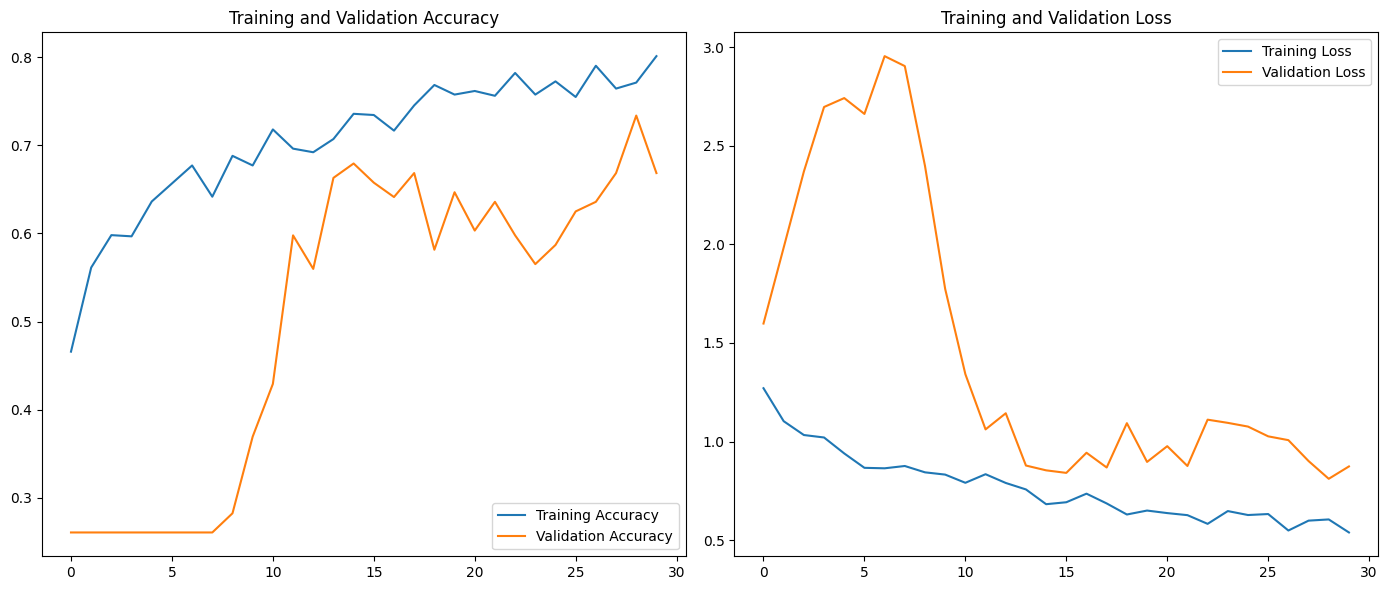

In [19]:
## Task 12:
## Your code here 
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [20]:
print("# of replicas:", NUM_REPLICAS)
print("training_accuracy:", training_accuracy)
print("validation_accuracy:", validation_accuracy)
print("training_time:", training_time, "s")

# of replicas: 4
training_accuracy: 0.7711171507835388
validation_accuracy: 0.7336956262588501
training_time: 99.47576141357422 s
